In [1]:
import sys
sys.path.insert(0, "../src")          # lets us import our own files from the src/ folder

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio, display

from features import SR, FRAME, HOP, split_into_frames, energy_db
from dataset import load_wav, list_clips, speech_labels, label_threshold, mix, build_frame_table, SNR_LEVELS


def play(y):
    """Show an audio player. normalize=False keeps the real loudness (silence stays quiet)."""
    display(Audio(np.clip(y, -1, 1), rate=SR, normalize=False))

In [2]:
for split in ["train", "test"]:
    for kind in ["clean_speech", "noise_only"]:
        print(f"{split:5s} {kind:13s} {len(list_clips(split, kind))} clips")

train clean_speech  30 clips
train noise_only    30 clips
test  clean_speech  20 clips
test  noise_only    20 clips


In [3]:
CLIP = 0

clean = load_wav(list_clips("train", "clean_speech")[CLIP])
noise = load_wav(list_clips("train", "noise_only")[CLIP])

print("Clean speech:", round(len(clean) / SR, 1), "seconds")
play(clean)
print("Noise only:", round(len(noise) / SR, 1), "seconds")
play(noise)

Clean speech: 20.0 seconds


Noise only: 20.0 seconds


Frames: 1998 | speech: 1759 | silence: 239


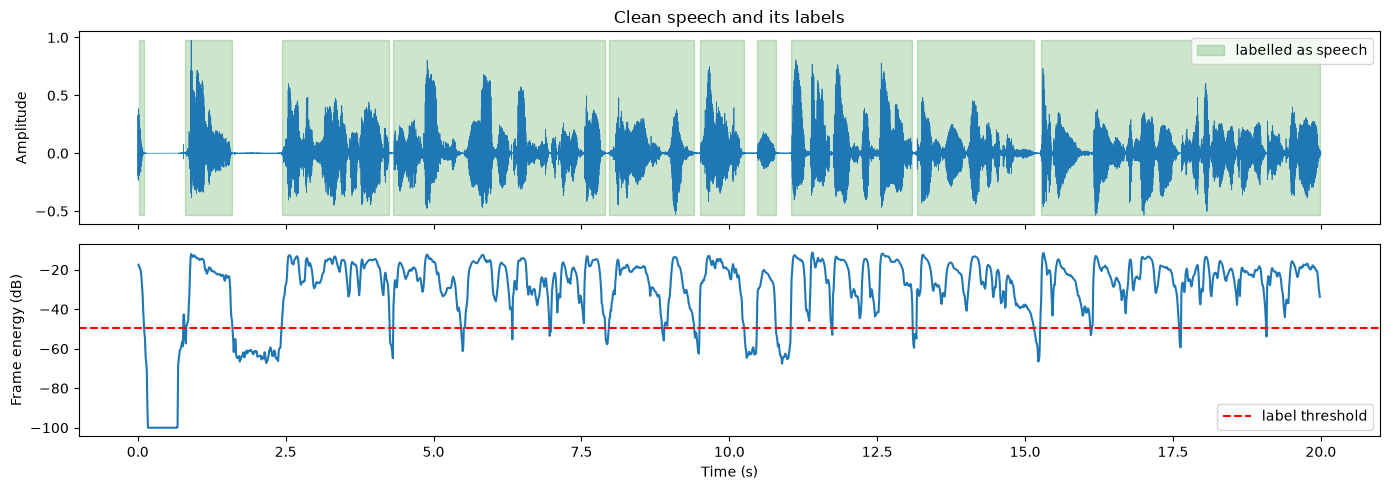

In [4]:
is_speech = speech_labels(clean)                       # True / False for every frame
frame_db = energy_db(split_into_frames(clean))         # loudness of every frame in dB

print("Frames:", len(is_speech), "| speech:", is_speech.sum(), "| silence:", (~is_speech).sum())

frame_time = (np.arange(len(is_speech)) * HOP + FRAME / 2) / SR     # centre of each frame in seconds
sample_time = np.arange(len(clean)) / SR

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(sample_time, clean, linewidth=0.5)
axes[0].fill_between(frame_time, clean.min(), clean.max(), where=is_speech, color="green", alpha=0.2,
                     label="labelled as speech")
axes[0].set_ylabel("Amplitude"); axes[0].legend(loc="upper right"); axes[0].set_title("Clean speech and its labels")
axes[1].plot(frame_time, frame_db)
axes[1].axhline(label_threshold(frame_db), color="red", linestyle="--", label="label threshold")
axes[1].set_ylabel("Frame energy (dB)"); axes[1].set_xlabel("Time (s)"); axes[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

In [ ]:
Grafiği nasıl okursun

Üst grafik (dalga şekli): Mavi çizgi sesin kendisi, yeşil bölgeler kodun “konuşma” dediği yerler. Mavi dalganın büyüdüğü her yer yeşil, düz kaldığı yerler beyaz. Yani etiket ile gözle gördüğün uyuşuyor.

Alt grafik (enerji): Her frame’in ne kadar yüksek sesli olduğu. Kırmızı çizgi eşik, yaklaşık −50 dB. Çizginin üstü konuşma, altı sessizlik.

Bu kayıtta görülen üç şey
Konuşma −10 ile −20 dB arasında, duraklamalar −60 dB civarında. Aralarında 40 dB’den fazla fark var; bu çok temiz bir kayıt demek. Eşik ikisinin tam arasına düşmüş.
0,1–0,7 saniye arası −100 dB. Bu gerçek bir sessizlik değil, dijital sıfır: kayda sonradan boşluk eklenmiş. 1,7–2,4 saniye arasındaki −60 dB ise gerçek ortam sessizliği. İkisi de “sessizlik” sınıfına giriyor; “ses var mı” sorusunda ikisinin farkı ilginç olacak.
En başta ince bir yeşil şerit var. Kaydın ilk anındaki kısa bir tık sesi konuşma sayılmış. Birkaç frame’lik küçük bir hata, sonucu etkilemez; ama hoca sorarsa “etiketler enerji kuralıyla otomatik üretiliyor, insan etiketi değil, böyle küçük hatalar olabiliyor” diyebilirsin.

Kelime içindeki kısa düşüşler (örneğin 5,5 ve 8 saniye civarı) enerji eşiğin altına inse de yeşil kalmış. Bu bilerek öyle: 11 frame’lik çoğunluk oylaması, bir kelimenin ortasındaki anlık boşlukları konuşmanın parçası sayıyor.

In [5]:
frames = split_into_frames(clean)
# Frames overlap (25 ms long, 10 ms apart), so we keep only the first 10 ms of each one when gluing
speech_only = frames[is_speech][:, :HOP].reshape(-1)
silence_only = frames[~is_speech][:, :HOP].reshape(-1)

print("Only the frames labelled speech:")
play(speech_only)
print("Only the frames labelled silence:")
play(silence_only)

Only the frames labelled speech:


Only the frames labelled silence:


Az önceki grafikte yeşil bölgeleri gözle gördün; burada aynı şeyi kulakla doğruluyoruz.

Fikir: Kaydı ikiye ayırıyoruz. “Konuşma” denen bütün parçaları bir araya getirip çalıyoruz, sonra “sessizlik” denen bütün parçaları bir araya getirip çalıyoruz.

Satır satır
python
frames = split_into_frames(clean)

Sesi 25 ms’lik parçalara böler. 20 saniyelik kayıt yaklaşık 2000 parça eder. frames bir tablo gibi: her satır bir parça, her satırda 400 sayı var.

python
speech_only = frames[is_speech][:, :HOP].reshape(-1)

Üç adım birden:

Parça	Ne yapıyor
frames[is_speech]	Yalnızca “konuşma” etiketli satırları seçer
[:, :HOP]	Her satırın ilk 160 sayısını (ilk 10 ms) alır
.reshape(-1)	Satırları uç uca ekleyip tek bir uzun ses yapar
python
silence_only = frames[~is_speech][:, :HOP].reshape(-1)

Aynısı, bu kez “sessizlik” etiketli satırlar için. ~ işareti “tersi” demek: is_speech’in False olduğu yerler.

python
play(speech_only)
play(silence_only)

İkisini çalar.

Neden her parçanın yalnızca ilk 10 ms’si?

Parçalar 25 ms uzunluğunda ama 10 ms arayla başlıyor, yani üst üste biniyorlar:

parça 1:  |-------- 25 ms --------|
parça 2:       |-------- 25 ms --------|
parça 3:            |-------- 25 ms --------|
          ^    ^    ^
          0   10   20 ms

Tamamını uç uca eklersek aynı ses üç kez tekrarlanır, yankılı ve bozuk duyulur. Her parçanın yalnızca ilk 10 ms’sini alınca her an tam bir kez geçer.

Ne duymalısın
İlk oynatıcı: Bütün kelimeler var, aradaki duraklamalar atılmış. Kişi hiç nefes almadan konuşuyor gibi duyulur.
İkinci oynatıcı: Hiç kelime yok; çok kısık bir hışırtı ya da neredeyse tam sessizlik. Süresi kısa olur, çünkü bu kayıtta sessizlik az.

In [6]:
examples_dir = Path("../examples")
examples_dir.mkdir(exist_ok=True)
sf.write(examples_dir / "clean.wav", clean, SR)
sf.write(examples_dir / "noise.wav", noise, SR)

for snr_db in SNR_LEVELS:
    noisy = mix(clean, noise, snr_db)
    added_noise = noisy - clean                         # what mix() added to the clean signal
    speech_power = np.mean(split_into_frames(clean)[is_speech] ** 2)
    measured_snr = 10 * np.log10(speech_power / np.mean(added_noise ** 2))
    print(f"Asked for {snr_db} dB, measured {measured_snr:.1f} dB")
    play(noisy)
    sf.write(examples_dir / f"speech_plus_noise_{snr_db}dB.wav", np.clip(noisy, -1, 1), SR)

Asked for 20 dB, measured 20.0 dB


Asked for 10 dB, measured 10.0 dB


Asked for 0 dB, measured 0.0 dB


Bu hücre temiz konuşmaya üç farklı seviyede gürültü ekliyor, her birini çalıyor ve dosyaya kaydediyor.

Neden yapıyoruz: “Konuşma var mı” sorusunu gürültülü ortamda da sormak istiyoruz. Gürültüyü kendimiz eklediğimiz için hem ne kadar gürültü olduğunu (SNR) hem de konuşmanın tam hangi anlarda olduğunu biliyoruz.

İlk dört satır: klasörü hazırla
python
examples_dir = Path("../examples")
examples_dir.mkdir(exist_ok=True)
sf.write(examples_dir / "clean.wav", clean, SR)
sf.write(examples_dir / "noise.wav", noise, SR)
Path("../examples"): Proje klasöründeki examples klasörünün yolu.
mkdir(exist_ok=True): Klasörü oluşturur; zaten varsa hata vermez.
sf.write(...): Temiz konuşmayı ve gürültüyü wav olarak yazar. SR (16000) dosyaya “saniyede 16000 sayı var” bilgisini koyar.
Döngü: her SNR için tekrarla
python
for snr_db in SNR_LEVELS:

SNR_LEVELS listesi [20, 10, 0]. Aşağıdaki satırlar üç kez çalışır: önce 20, sonra 10, sonra 0 için.

python
    noisy = mix(clean, noise, snr_db)

Asıl iş burada. mix üç şey yapar:

Gürültüyü konuşmayla aynı uzunluğa getirir (kısaysa tekrarlar, uzunsa keser).
Gürültüyü, istenen SNR’ı verecek sayıyla çarpar.
Konuşmayla toplar.

Sonuç noisy: gürültülü konuşma. Konuşmanın kendisi hiç değişmez, yalnızca gürültünün seviyesi ayarlanır.

Sağlama: gerçekten istediğimiz SNR mı?
python
    added_noise = noisy - clean

Karışımdan temiz konuşmayı çıkarınca geriye yalnızca eklenen gürültü kalır.

python
    speech_power = np.mean(split_into_frames(clean)[is_speech] ** 2)

Konuşmanın gücü: yalnızca “konuşma” etiketli parçalardaki sayıların karesinin ortalaması. Duraklamaları saymıyoruz, yoksa uzun duraklamalı bir kayıtta konuşma olduğundan zayıf görünür.

python
    measured_snr = 10 * np.log10(speech_power / np.mean(added_noise ** 2))

SNR formülünün kendisi:

SNR = 10 × log10(konuşma gücü / gürültü gücü)

python
    print(f"Asked for {snr_db} dB, measured {measured_snr:.1f} dB")

İstenen ile ölçüleni yan yana yazar. Aynı çıkmalı; çıkıyorsa mix doğru çalışıyor.

Çal ve kaydet
python
    play(noisy)
    sf.write(examples_dir / f"speech_plus_noise_{snr_db}dB.wav", np.clip(noisy, -1, 1), SR)
play(noisy): Notebook’ta oynatıcı gösterir.
sf.write(...): speech_plus_noise_20dB.wav gibi bir adla kaydeder. np.clip(noisy, -1, 1) ise −1 ile 1 dışına taşan değerleri keser; wav dosyaları bu aralıkta olmak zorunda.
SNR sayıları ne anlama geliyor
SNR	Konuşma gürültüden kaç kat güçlü	Nasıl duyulur
20 dB	100 kat	Gürültü arkada hafifçe var
10 dB	10 kat	Gürültü belirgin, konuşma rahat anlaşılıyor
0 dB	1 kat (eşit)	İkisi aynı seviyede, anlamak zorlaşıyor

Her 10 dB düşüş, gürültünün 10 kat güçlenmesi demek.

In [7]:
table = build_frame_table("train", max_clips=3)
display(table.groupby(["condition", "klass"]).size().unstack(fill_value=0))
display(table[["klass", "audio", "speech"]].drop_duplicates().reset_index(drop=True))

klass,noise,silence,speech
condition,,,
clean speech,0,940,5054
noise only,5994,0,0
speech + noise 0 dB,940,0,5054
speech + noise 10 dB,940,0,5054
speech + noise 20 dB,940,0,5054


,klass,audio,speech
0,noise,1,0
1,speech,1,1
2,silence,0,0


table = build_frame_table("train", max_clips=3)

Hücre 4 ve 6'da tek bir kayıt için elle yaptığın işleri birkaç kayıt için otomatik yapar:

İlk 3 gürültü kaydını okur; bütün parçalarına noise der.
İlk 3 temiz konuşma kaydını okur; her parçaya speech ya da silence der (hücre 4'teki kural).
Her temiz kaydı bir gürültüyle 20, 10 ve 0 dB’de karıştırır (hücre 6'daki mix).
Hepsini tek bir büyük tabloda toplar. Her satır 25 ms’lik bir parça; sütunlarda feature’lar ve etiketler var.
python
display(table.groupby(["condition", "klass"]).size().unstack(fill_value=0))

Parçaları koşula ve sınıfa göre sayar; ilk tablo bu.

python
display(table[["klass", "audio", "speech"]].drop_duplicates().reset_index(drop=True))

Her sınıfın iki soruda hangi cevaba karşılık geldiğini gösterir; ikinci tablo bu.

İlk tablo: kaç parça, hangi sınıf
Koşul	noise	silence	speech
clean speech	0	940	5054
noise only	5994	0	0
speech + noise 0 dB	940	0	5054
speech + noise 10 dB	940	0	5054
speech + noise 20 dB	940	0	5054
Her satırın toplamı 5994. 3 kayıt × 20 saniye, her saniyede yaklaşık 100 parça.
Temiz konuşmada parçaların 5054'ü konuşma, 940'ı sessizlik. Yani kayıtların yaklaşık %84'ü konuşma, %16'sı duraklama.
Yalnız gürültüde hepsi noise.
En önemli satırlar son üçü: Temizdeki 940 sessizlik parçası, gürültü eklenince noise sütununa geçmiş. Çünkü duraklama artık sessiz değil, içinde gürültü var. Konuşma sayısı (5054) değişmemiş; konuşmanın yeri aynı, yalnızca üstüne gürültü binmiş.
İkinci tablo: sınıflar iki soruya nasıl dönüşüyor
klass	audio (ses var mı)	speech (konuşma var mı)
noise	1	0
speech	1	1
silence	0	0

Projenin bütün mantığı bu üç satırda:

Gürültü: Ses var, konuşma yok.
Konuşma: İkisi de var.
Sessizlik: İkisi de yok.
Dikkat etmen gereken bir şey

Konuşma parçaları (5054) sessizlikten (940) beş kat fazla. Sınıflar dengesiz. Bu yüzden notebook 03'te düz accuracy yerine balanced accuracy kullanacağız: her şeye “konuşma” diyen biri düz accuracy’de %84 alır, balanced accuracy’de tam %50.